# Investigate Hotel Business 

### Loading python libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Dataset Loading

In [2]:
df = pd.read_csv("hotel_bookings_data.csv")

#### First 5 rows view

In [3]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_weekdays_nights,adults,...,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status
0,Resort Hotel,0,342,2017,September,27,1,0,0,2,...,3,No Deposit,NaN,NaN,0,Personal,0.0,0,0,Check-Out
1,Resort Hotel,0,737,2017,September,27,1,0,0,2,...,4,No Deposit,NaN,NaN,0,Personal,0.0,0,0,Check-Out
2,Resort Hotel,0,7,2017,September,27,1,0,1,1,...,0,No Deposit,NaN,NaN,0,Personal,75.0,0,0,Check-Out
3,Resort Hotel,0,13,2017,September,27,1,0,1,1,...,0,No Deposit,304.0,NaN,0,Personal,75.0,0,0,Check-Out
4,Resort Hotel,0,14,2017,September,27,1,0,2,2,...,0,No Deposit,240.0,NaN,0,Personal,98.0,0,1,Check-Out


### Statistical View of Dataset of only numerical columns

In [4]:
df.describe(include='number')

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_weekdays_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2018.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2017.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2018.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2018.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2019.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2019.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


#### Dataset Anamolies check

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 29 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_weekdays_nights        119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

### Check for missing values

In [6]:
df[df['children'].isna()].T

,40600,40667,40679,41160
hotel,City Hotel,City Hotel,City Hotel,City Hotel
is_canceled,1,1,1,1
lead_time,2,1,1,8
arrival_date_year,2017,2017,2017,2017
arrival_date_month,October,October,October,October
arrival_date_week_number,32,32,32,33
arrival_date_day_of_month,3,5,5,13
stays_in_weekend_nights,1,0,0,2
stays_in_weekdays_nights,0,2,2,5
adults,2,2,3,2


In [7]:
df['children'].isna().sum()

np.int64(4)

#### Children columns is identified with 4 NaN values and we decided it to fill with 0 insead

In [8]:
df['children'] = df['children'].fillna(0)

##### After filling with 0 in children column

In [9]:
df['children'].isna().sum()

np.int64(0)

#### Typecasted in integer

In [10]:
df['children'] = df['children'].astype(int) 

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 29 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_weekdays_nights        119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119390 non-null  int64  
 11  babies                          119390 non-null  int64  
 12  meal                       

In [12]:
df.isna().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_weekdays_nights               0
adults                                 0
children                               0
babies                                 0
meal                                   0
city                                 488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
booking_changes                        0
deposit_type                           0
agent                              16340
company                           112593
days_in_waiting_list                   0
customer_type   

From the above null values present in columns like company, agent, city
The column company specifically needed to dropped because there is no relation of this column with other columns

In [13]:
df.drop(columns=['company'],inplace=True)

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 28 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_weekdays_nights        119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119390 non-null  int64  
 11  babies                          119390 non-null  int64  
 12  meal                       

In [15]:
df.isna().sum()

hotel                                 0
is_canceled                           0
lead_time                             0
arrival_date_year                     0
arrival_date_month                    0
arrival_date_week_number              0
arrival_date_day_of_month             0
stays_in_weekend_nights               0
stays_in_weekdays_nights              0
adults                                0
children                              0
babies                                0
meal                                  0
city                                488
market_segment                        0
distribution_channel                  0
is_repeated_guest                     0
previous_cancellations                0
previous_bookings_not_canceled        0
booking_changes                       0
deposit_type                          0
agent                             16340
days_in_waiting_list                  0
customer_type                         0
adr                                   0


1. Agent columns have 16340 NaN values which means there might be direct bookings but not via agent or through travel agent.

Decision - To populate the null values in agent column with 0.0

2. Column city is having 488 NaN values which might shows that there are customers who havenot provided their city while providing the address.

Decision - To populate with the "Unknown" is worthfilling.

In [16]:
df['agent'] = df['agent'].fillna(0.0)

In [17]:
df['city'] = df['city'].fillna('Unknown')

In [18]:
df.isna().sum()

hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_weekdays_nights          0
adults                            0
children                          0
babies                            0
meal                              0
city                              0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
booking_changes                   0
deposit_type                      0
agent                             0
days_in_waiting_list              0
customer_type                     0
adr                               0
required_car_parking_spaces       0
total_of_special_requests         0
reservation_status          

In [19]:
df.head().T

,0,1,2,3,4
hotel,Resort Hotel,Resort Hotel,Resort Hotel,Resort Hotel,Resort Hotel
is_canceled,0,0,0,0,0
lead_time,342,737,7,13,14
arrival_date_year,2017,2017,2017,2017,2017
arrival_date_month,September,September,September,September,September
arrival_date_week_number,27,27,27,27,27
arrival_date_day_of_month,1,1,1,1,1
stays_in_weekend_nights,0,0,0,0,0
stays_in_weekdays_nights,0,0,1,1,2
adults,2,2,1,1,2


Since Day of Month, Month, Year is separated in separate columns. I decided to concat them together in a single datetime column
Removing the columns Day_name, Month and Year column.

In [20]:
days_in_month = {'January':31,'February':28,'March':31,'April':30,'May':31,'June':30,
                  'July':31,'August':31,'September':30,'October':31,'November':30,'December':31}
df['_max_day'] = df['arrival_date_month'].map(days_in_month)
df = df[df['arrival_date_day_of_month'] <= df['_max_day']].drop(columns=['_max_day'])

df['arrival_date'] = pd.to_datetime(
    df['arrival_date_day_of_month'].astype(str) + '-' +
    df['arrival_date_month'] + '-' +
    df['arrival_date_year'].astype(str),
    format='%d-%B-%Y'
)

In [21]:
df.head().T

,0,1,2,3,4
hotel,Resort Hotel,Resort Hotel,Resort Hotel,Resort Hotel,Resort Hotel
is_canceled,0,0,0,0,0
lead_time,342,737,7,13,14
arrival_date_year,2017,2017,2017,2017,2017
arrival_date_month,September,September,September,September,September
arrival_date_week_number,27,27,27,27,27
arrival_date_day_of_month,1,1,1,1,1
stays_in_weekend_nights,0,0,0,0,0
stays_in_weekdays_nights,0,0,1,1,2
adults,2,2,1,1,2


A quick checks whether the colmun have proper date format

In [22]:
df['arrival_date'].head(20)

0    2017-09-01
1    2017-09-01
2    2017-09-01
3    2017-09-01
4    2017-09-01
5    2017-09-01
6    2017-09-01
7    2017-09-01
8    2017-09-01
9    2017-09-01
10   2017-09-01
11   2017-09-01
12   2017-09-01
13   2017-09-01
14   2017-09-01
15   2017-09-01
16   2017-09-01
17   2017-09-01
18   2017-09-01
19   2017-09-01
Name: arrival_date, dtype: datetime64[us]

In [23]:
df['arrival_date'].dtype

dtype('<M8[us]')

In [24]:
df['arrival_date'].dt.month.tail()

119385    10
119386    10
119387    10
119388    10
119389    10
Name: arrival_date, dtype: int32

In [25]:
df['arrival_date'].dt.day_name().head()

0    Friday
1    Friday
2    Friday
3    Friday
4    Friday
Name: arrival_date, dtype: str

In [26]:
df.drop(columns=['arrival_date_year','arrival_date_month','arrival_date_day_of_month'],inplace=True)

In [27]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_week_number',
       'stays_in_weekend_nights', 'stays_in_weekdays_nights', 'adults',
       'children', 'babies', 'meal', 'city', 'market_segment',
       'distribution_channel', 'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'booking_changes', 'deposit_type',
       'agent', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'arrival_date'],
      dtype='str')

In [28]:
df.duplicated().sum()

np.int64(32979)

Decided to keep Duplicates values as these can be different guests who happen to book the same hotel, same date, same room type, same price, etc. would look identical.

In [29]:
df[df.duplicated(keep=False)].sort_values(by=list(df.columns)).head(10).T

,104294,104295,82952,82971,46512,46514,104410,104415,104754,104765
hotel,City Hotel,City Hotel,City Hotel,City Hotel,City Hotel,City Hotel,City Hotel,City Hotel,City Hotel,City Hotel
is_canceled,0,0,0,0,0,0,0,0,0,0
lead_time,0,0,0,0,0,0,0,0,0,0
arrival_date_week_number,2,2,2,2,2,2,2,2,3,3
stays_in_weekend_nights,0,0,0,0,1,1,1,1,0,0
stays_in_weekdays_nights,1,1,1,1,0,0,3,3,1,1
adults,2,2,2,2,1,1,2,2,1,1
children,0,0,0,0,0,0,0,0,0,0
babies,0,0,0,0,0,0,0,0,0,0
meal,No Meal,No Meal,No Meal,No Meal,Breakfast,Breakfast,Breakfast,Breakfast,No Meal,No Meal


In [30]:
print(df.shape)

(118032, 26)


In [31]:
df['adr'].agg(['min','max','mean','median']).to_frame().T

,min,max,mean,median
adr,-6.38,5400.0,101.50277,94.5


Insights:
1. The min average_daily_rate is -6.38 which is impossible for an hotel to charge their customer. Money charged is in positive
2. Max adr is 5400 and the next highest adr is 510 which shows a high jump and 10x of the next highest value. 
Looks like data entry error or missing decimal of adding extra 0. Not a luxury bookeing either.
3. The mean and median 101.50 is in normal range.

In [32]:
df[df['adr']==5400].T  # inspect the full row first

,48515
hotel,City Hotel
is_canceled,1
lead_time,35
arrival_date_week_number,13
stays_in_weekend_nights,0
stays_in_weekdays_nights,1
adults,2
children,0
babies,0
meal,Breakfast


This booking with high adr is canceled and its reservation_status is canceled. Also for 2 adults for weekdays night is charged terrible

Better to drop this entry to not let the further analysis get influenced from it.

In [33]:
df = df[df['adr']!=5400]

In [34]:
df[df['adr']<0].T

,14969
hotel,Resort Hotel
is_canceled,0
lead_time,195
arrival_date_week_number,10
stays_in_weekend_nights,4
stays_in_weekdays_nights,6
adults,2
children,0
babies,0
meal,Breakfast


From the above information about the booking, it shows the hotel charged ADR in negative which is not possible.

It might be data entry error. I decided to drop it to not the let the further analysis influenced by it.

In [35]:
df = df[df['adr']>=0]

ADR charged 0 have strong reason behind. The booking might be:
- Complementary, 
- Promotional
- Customer Loyalty Points reward

Last but not the least
- Data Logging error

In [36]:
adr_zero = (df['adr']==0).sum()

1935 rows with ADR charged 0 also have strong connection with "market_segment" and "Customer_type" columns becuase of the customer loyalty and booking behaviour

In [37]:
df[df['adr']==0]['market_segment'].value_counts()

market_segment
Complementary    673
Online TA        365
Offline TA/TO    331
Groups           240
Direct           238
Corporate         82
Aviation           6
Name: count, dtype: int64

In [38]:
df[df['adr']==0]['customer_type'].value_counts()

customer_type
Personal     1440
Family        439
Bussiness      33
Contract       23
Name: count, dtype: int64

"Customer_type breakdown shows most zero-adr bookings fall under Personal (1,440) and Family (439), suggesting these may be comp stays, loyalty rewards, or promotional offers rather than data errors — supported by their much lower cancellation rate (10.9%) vs the dataset average (37%)."

In [39]:
df.head().T

,0,1,2,3,4
hotel,Resort Hotel,Resort Hotel,Resort Hotel,Resort Hotel,Resort Hotel
is_canceled,0,0,0,0,0
lead_time,342,737,7,13,14
arrival_date_week_number,27,27,27,27,27
stays_in_weekend_nights,0,0,0,0,0
stays_in_weekdays_nights,0,0,1,1,2
adults,2,2,1,1,2
children,0,0,0,0,0
babies,0,0,0,0,0
meal,Breakfast,Breakfast,Breakfast,Breakfast,Breakfast


In [40]:
df['meal'] = df['meal'].replace('Undefined','Self-Catering')

In [41]:
df.groupby('meal',observed=False)['city'].count().sort_values(ascending=False)

meal
Breakfast        91299
Dinner           14321
No Meal          10547
Self-Catering     1068
Full Board         795
Name: city, dtype: int64

"Breakfast is the most common meal plan among guests (91,299 bookings), suggesting most guests prefer or default to a bed-and-breakfast package over self-catering or full board options."

To Handle bookings with zero-guest - babies = 0, childern = 0 and adults = 0 happened to be simultanouesly

In [42]:
sum_of_zero_guest = ((df['adults']==0) & (df['children'].fillna(0)==0) & (df['babies']==0)).sum()
sum_of_zero_guest

np.int64(177)

In [43]:
df = df[~((df['adults']==0) & (df['children'].fillna(0)==0) & (df['babies']==0))]

### Data Analysis (Core EDA)

1. Univariate (one column at a time)

1.1 Chart the share of bookings: City Hotel vs Resort Hotel.

In [44]:
df['hotel'].value_counts()

hotel
City Hotel      78370
Resort Hotel    39483
Name: count, dtype: int64

In [45]:
hotel_booking = df['hotel'].value_counts().to_frame().reset_index()
hotel_booking['booking_percentage'] = round(hotel_booking['count']/hotel_booking['count'].sum()*100,2)
hotel_booking

,hotel,count,booking_percentage
0,City Hotel,78370,66.5
1,Resort Hotel,39483,33.5


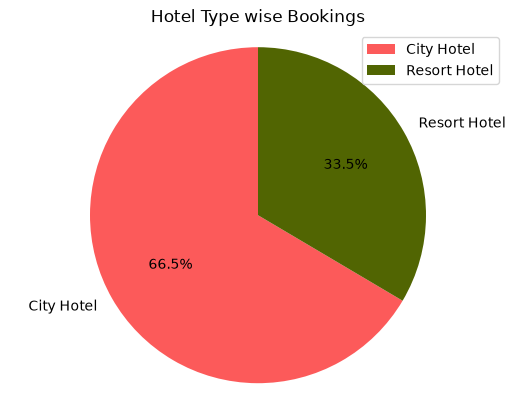

In [46]:
plt.Figure(figsize=(10,6))
hotel_booking.plot.pie(
    x='hotel',
    y='count',
    labels=hotel_booking['hotel'],
    autopct='%1.1f%%',
    startangle=90,colors=["#FC5A5A","#516502"])
plt.title('Hotel Type wise Bookings')
plt.axis('equal')
plt.show()

1.2 — Meal plan distribution

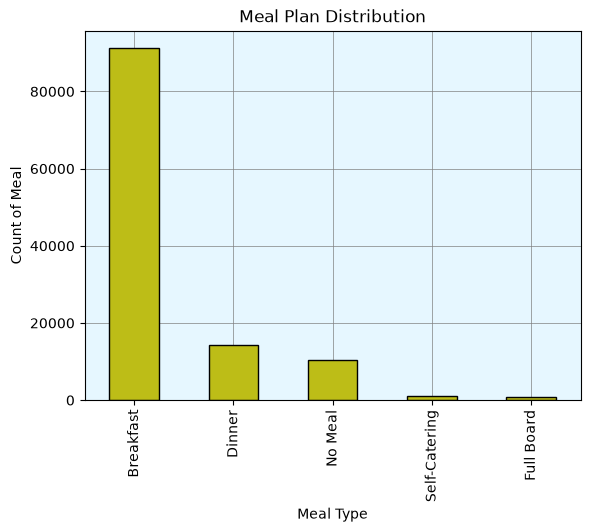

In [47]:
df['meal'].value_counts().plot(
    kind='bar',
    x='meal',
    y='count',
    color='#BDBD17',
    edgecolor='black')

plt.gca().set_facecolor('#e6f7ff')

plt.title('Meal Plan Distribution')
plt.xlabel('Meal Type')
plt.ylabel('Count of Meal')
plt.grid(True,color='grey',linestyle='-',linewidth=0.5)
plt.gca().set_axisbelow(True)

plt.show()

Insights

- Breakfast is the most common meal plan, chosen in ~77.4% of bookings
- Dinner is second at ~12.1%, followed by No Meal at ~8.9%
- Self-Catering (recategorized from "Undefined") makes up a small ~0.9%
- Full Board is the least common at ~0.7%
- Most guests default to or prefer a bed-and-breakfast style package over self-catering or full board — likely reflecting both guest preference and standard hotel bundling

1.3 — ADR (average daily rate) distribution

In [48]:
df['adr'].describe()

count    117853.000000
mean        101.595212
std          47.701484
min           0.000000
25%          69.000000
50%          94.500000
75%         125.800000
max         510.000000
Name: adr, dtype: float64

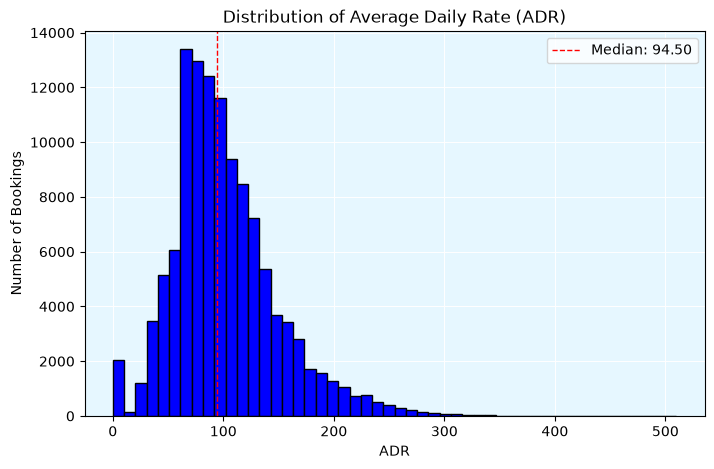

In [66]:
median_adr = df['adr'].median()

plt.figure(figsize=(8,5))
plt.gca().set_facecolor('#e6f7ff')   # sky blue background panel

plt.hist(df['adr'], bins=50, color='blue',edgecolor='black')
plt.axvline(median_adr, color='red', linestyle='--', linewidth=1, label=f'Median: {median_adr:.2f}')
plt.title('Distribution of Average Daily Rate (ADR)')
plt.xlabel('ADR')
plt.ylabel('Number of Bookings')
plt.legend()

plt.grid(True, color='white', linestyle='-', linewidth=0.7)
plt.gca().set_axisbelow(True)

plt.show()

Insights:

- 50% of bookings fall between 69 and 125.8 per night (25th–75th percentile)
- Median ADR is 94.5, showing prices cluster around a moderate, budget-to-midscale range
- Mean ADR (101.6) is slightly higher than the median, indicating a right-skewed distribution with some higher-priced bookings pulling the average up
- Range is 0–510 after cleaning — no more negative values or extreme 5400-type outliers
- Overall, pricing is fairly consistent across most bookings, with only a small tail of premium-priced stays

### 2. Bivariate Analysis

2.1 Calculate the chart cancellation rate per hotel type (hotel vs is_canceled).

In [50]:
total_bookings = df.groupby('hotel')['hotel'].value_counts()
total_bookings

hotel
City Hotel      78370
Resort Hotel    39483
Name: count, dtype: int64

In [51]:
canceled_booking = df[df['is_canceled']==1].groupby('hotel')['hotel'].value_counts()
canceled_booking

hotel
City Hotel      32757
Resort Hotel    10979
Name: count, dtype: int64

In [52]:
cancel_rate = (canceled_booking/total_bookings*100).round(2)
cancel_rate

hotel
City Hotel      41.80
Resort Hotel    27.81
Name: count, dtype: float64

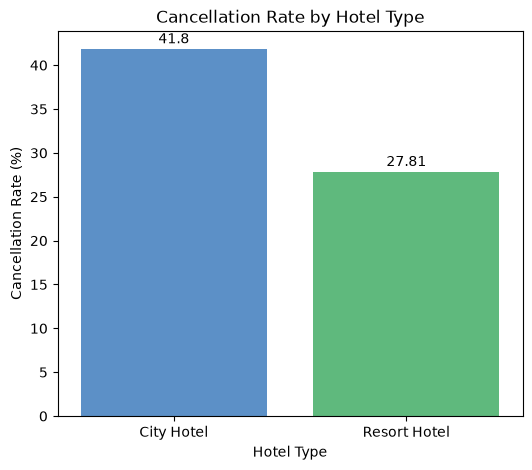

In [53]:
plt.figure(figsize=(6,5))
z = sns.barplot(
    x=cancel_rate.index, 
    y=cancel_rate.values, 
    hue=cancel_rate.index, 
    palette=['#4a90d9','#50c878'], 
    legend=False)

plt.title('Cancellation Rate by Hotel Type')
plt.xlabel('Hotel Type')
plt.ylabel('Cancellation Rate (%)')
for i in z.containers:
    z.bar_label(i,padding=2)
plt.show()

Insights:

- City Hotel has a noticeably higher cancellation rate (~42%) compared to Resort Hotel (~28%)
- Gap of roughly 14 percentage points between the two hotel types
- Possible reasons for City Hotel's higher cancellations:
    - More flexible booking/cancellation plans
    - Business travel changes (meetings rescheduled, trips cancelled)
    - Price-sensitive guests more likely to cancel or rebook elsewhere
- Resort Hotel's lower rate may reflect more vacation-planned, non-refundable, or advance-committed bookings

2.2 Deposit type vs. cancellation

Does requiring a deposit make guests less likely to cancel?

In [54]:
deposit_cancel = round(df.groupby('deposit_type')['is_canceled'].mean() * 100,2)
deposit_cancel

deposit_type
No Deposit    28.38
Non Refund    99.37
Refundable    20.75
Name: is_canceled, dtype: float64

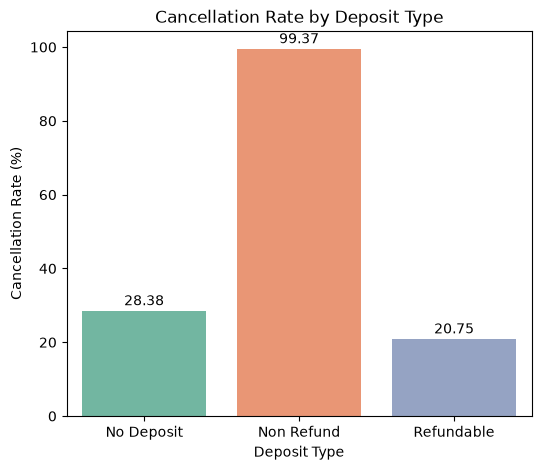

In [55]:
plt.figure(figsize=(6,5))
d = sns.barplot(
    x=deposit_cancel.index, 
    y=deposit_cancel.values, 
    hue=deposit_cancel.index, 
    palette='Set2', 
    legend=False)

plt.title('Cancellation Rate by Deposit Type')
plt.xlabel('Deposit Type')
plt.ylabel('Cancellation Rate (%)')
for i in d.containers:
    d.bar_label(i,padding=2)
plt.show()

Insights

- Non Refund bookings have an extremely high cancellation rate: 99.37% — almost every single one cancels
- No Deposit bookings cancel at 28.38%
- Refundable bookings cancel the least, at 20.75%

- This is highly counter-intuitive — you'd expect a non-refundable deposit to discourage cancellation, since the guest loses money, but the opposite is true here
- Likely explanation: this isn't guests forfeiting money by choice — it may reflect fraudulent/no-show bookings, agent-bulk-holds, or a data-labeling quirk where "cancelled" status gets applied differently for this booking type
- Only 14,508 bookings fall into Non Refund (~12% of data), and just 159 are Refundable — small enough for Refundable that the % is less statistically reliable

2.3 Repeat guest vs. cancellation

In [56]:
repeat_cancel = round(df.groupby('is_repeated_guest')['is_canceled'].mean() * 100,2)
repeat_cancel

is_repeated_guest
0    37.84
1    14.64
Name: is_canceled, dtype: float64

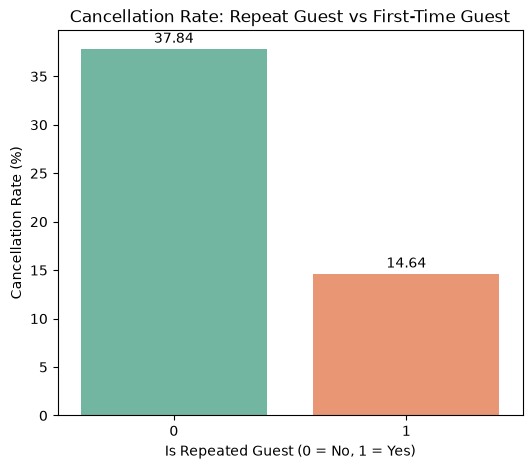

In [57]:
plt.figure(figsize=(6,5))
r = sns.barplot(
    x=repeat_cancel.index, 
    y=repeat_cancel.values, 
    hue=repeat_cancel.index, 
    palette='Set2', 
    legend=False)

plt.title('Cancellation Rate: Repeat Guest vs First-Time Guest')
plt.xlabel('Is Repeated Guest (0 = No, 1 = Yes)')
plt.ylabel('Cancellation Rate (%)')
for i in r.containers:
    r.bar_label(i,padding=2) 
plt.show()

Insights

- First-time guests cancel at 37.84%
- Repeat guests cancel at just 14.64% — less than half the rate of first-timers
- Clear, intuitive pattern: guests who've stayed before are far more likely to follow through on their booking, likely due to trust, familiarity, or loyalty to the hotel
- However, repeat guests make up only 3,715 of 117,853 bookings (~3.2%) — a small but meaningful segment worth targeting for retention, since they're by far the most reliable customer group

### 3. Multivariate

3.1 Monthly bookings by hotel type (month + hotel + count).

In [58]:
df['month'] = df['arrival_date'].dt.month_name()

# keep months in calendar order, not alphabetical
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']
df['month'] = pd.Categorical(df['month'], categories=month_order, ordered=True)

monthly_hotel = df.groupby(['month','hotel'], observed=True).size().reset_index(name='bookings')
monthly_hotel

,month,hotel,bookings
0,January,City Hotel,4336
1,January,Resort Hotel,2435
2,February,City Hotel,3513
3,February,Resort Hotel,2256
4,March,City Hotel,3730
5,March,Resort Hotel,2191
6,April,City Hotel,4950
7,April,Resort Hotel,3102
8,May,City Hotel,6433
9,May,Resort Hotel,3333


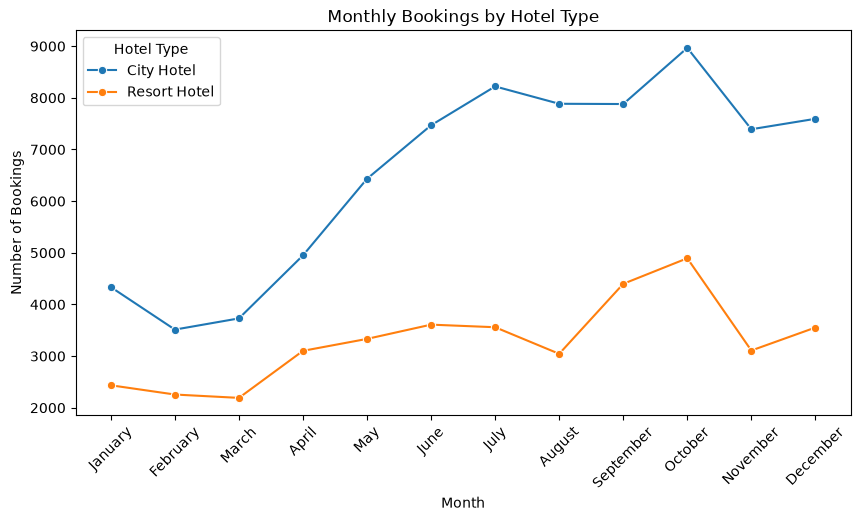

In [59]:
plt.figure(figsize=(10,5))
sns.lineplot(data=monthly_hotel, x='month', y='bookings', hue='hotel', marker='o')
plt.title('Monthly Bookings by Hotel Type')
plt.xlabel('Month')
plt.ylabel('Number of Bookings')
plt.xticks(rotation=45)
plt.legend(title='Hotel Type')
plt.show()

Insights:

- October is peak season for both hotel types (highest bookings)
- City Hotel's low point: February; Resort Hotel's low point: March
- City Hotel outsells Resort Hotel every single month — steadier, less seasonal demand
- Resort Hotel bookings are more tied to vacation season (summer–fall surge)
- Clear seasonal pattern: low in Jan–Mar, rising through summer, peaking around Oct
- Takeaway: use Jan–Mar for maintenance/promotions, staff up for the October peak

3.2 Plot cancellation rate vs. total length of stay, for both hotel types. (stay length + hotel + is_canceled)

In [60]:
# Total Stay length is calculated by adding total number of weekdays stay and weekend stay
df['total_stay'] = df['stays_in_weekend_nights'] + df['stays_in_weekdays_nights']


In [63]:
df['total_stay'] = df['stays_in_weekend_nights'] + df['stays_in_weekdays_nights']

def stay_bucket(n):
    if n <= 3:
        return '1-3 nights'
    elif n <= 7:
        return '4-7 nights'
    elif n <= 14:
        return '8-14 nights'
    else:
        return '15+ nights'

df['stay_bucket'] = df['total_stay'].apply(stay_bucket)

bucket_order = ['1-3 nights','4-7 nights','8-14 nights','15+ nights']
df['stay_bucket'] = pd.Categorical(df['stay_bucket'], categories=bucket_order, ordered=True)

stay_cancel = df.groupby(['stay_bucket','hotel'], observed=True)['is_canceled'].mean().reset_index()
stay_cancel['cancel_rate'] = stay_cancel['is_canceled'] * 100
stay_cancel

,stay_bucket,hotel,is_canceled,cancel_rate
0,1-3 nights,City Hotel,0.427544,42.754388
1,1-3 nights,Resort Hotel,0.237887,23.788725
2,4-7 nights,City Hotel,0.385255,38.525515
3,4-7 nights,Resort Hotel,0.322562,32.256229
4,8-14 nights,City Hotel,0.521947,52.194656
5,8-14 nights,Resort Hotel,0.288763,28.876283
6,15+ nights,City Hotel,0.768212,76.821192
7,15+ nights,Resort Hotel,0.451264,45.126354


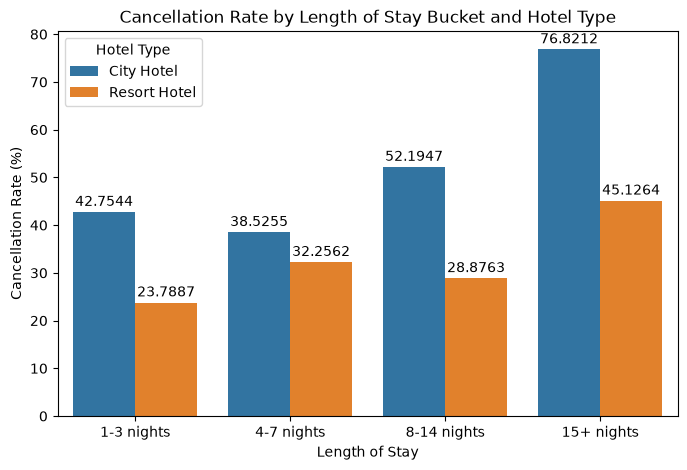

In [67]:
plt.figure(figsize=(8,5))
c = sns.barplot(data=stay_cancel, x='stay_bucket', y='cancel_rate', hue='hotel')
plt.title('Cancellation Rate by Length of Stay Bucket and Hotel Type')
plt.xlabel('Length of Stay')
plt.ylabel('Cancellation Rate (%)')
plt.legend(title='Hotel Type')
for i in c.containers:
    c.bar_label(i,padding=2)
plt.show()

**Insight:**
- Cancellation rate rises with stay length for both hotel types, but far more sharply for City Hotel
- City Hotel: 42.75% (1-3 nights) → 76.82% (15+ nights)
- Resort Hotel: 23.79% (1-3 nights) → 45.13% (15+ nights) — a much gentler rise
- City Hotel cancels more at every stay length, but the gap widens dramatically for longer stays
- Note: 15+ night bookings are rare (151 City, 277 Resort out of 117,853 rows), so this segment's rate is less statistically stable than shorter stays
- Longer bookings likely carry more uncertainty (schedule changes, budget shifts), and City Hotel's more flexible/business-driven guests may be quicker to cancel than Resort Hotel's vacation-committed guests

3.3 Does lead time affect cancellation rate, and does it differ by hotel type?

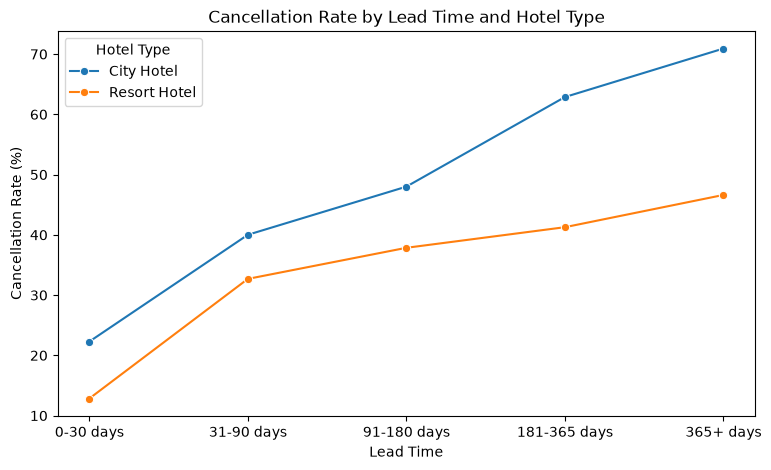

In [ ]:
def lt_bucket(n):
    if n <= 30:
        return '0-30 days'
    elif n <= 90:
        return '31-90 days'
    elif n <= 180:
        return '91-180 days'
    elif n <= 365:
        return '181-365 days'
    else:
        return '365+ days'

df['lt_bucket'] = df['lead_time'].apply(lt_bucket)
lt_order = ['0-30 days','31-90 days','91-180 days','181-365 days','365+ days']
df['lt_bucket'] = pd.Categorical(df['lt_bucket'], categories=lt_order, ordered=True)

lt_cancel = df.groupby(['lt_bucket','hotel'], observed=True)['is_canceled'].mean().reset_index()
lt_cancel['cancel_rate'] = round(lt_cancel['is_canceled']*100, 2)

plt.figure(figsize=(9,5))
sns.lineplot(data=lt_cancel, x='lt_bucket', y='cancel_rate', hue='hotel', marker='o')
plt.title('Cancellation Rate by Lead Time and Hotel Type')
plt.xlabel('Lead Time')
plt.ylabel('Cancellation Rate (%)')
plt.legend(title='Hotel Type')
plt.show()

**Insight:**
- Cancellation rate climbs steadily with lead time for both hotel types
- City Hotel: 22.28% (0-30 days) → 70.92% (365+ days)
- Resort Hotel: 12.83% (0-30 days) → 46.62% (365+ days)
- Lowest cancellation for both types is bookings made within 30 days of arrival — guests booking last-minute are far more committed
- Highest cancellation is for bookings made 365+ days out — plans made a year ahead are most likely to change
- City Hotel is consistently and substantially higher than Resort Hotel at every lead-time bracket, and the gap widens as lead time increases
- Business takeaway: hotels could tighten deposit/cancellation policies specifically for bookings made 90+ days in advance, especially for City Hotel

3.4 How does average daily rate (ADR) change across months, and does the pattern differ by hotel type?

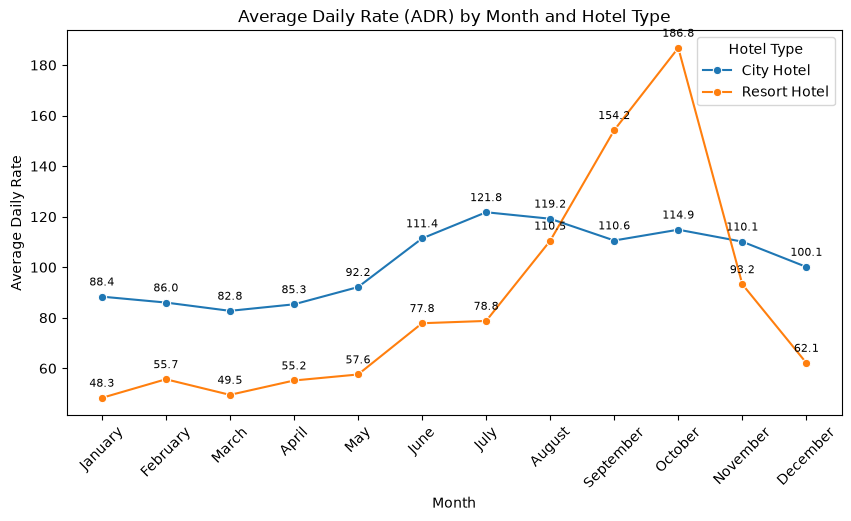

In [69]:
adr_month = df.groupby(['month','hotel'], observed=True)['adr'].mean().reset_index()
adr_month['adr'] = round(adr_month['adr'], 2)

plt.figure(figsize=(10,5))
ax = sns.lineplot(data=adr_month, x='month', y='adr', hue='hotel', marker='o')

for _, row in adr_month.iterrows():
    ax.annotate(f"{row['adr']:.1f}",
                (row['month'], row['adr']),
                textcoords="offset points",
                xytext=(0, 8),
                ha='center',
                fontsize=8)

plt.title('Average Daily Rate (ADR) by Month and Hotel Type')
plt.xlabel('Month')
plt.ylabel('Average Daily Rate')
plt.xticks(rotation=45)
plt.legend(title='Hotel Type')
plt.show()

Insight:
- City Hotel's ADR stays relatively stable, ranging from ~83 (March) to ~122 (July) — a moderate,
  fairly flat curve year-round
- Resort Hotel's ADR swings far more dramatically — from a low of ~48 (January) to a striking peak
  of ~187 (October), overtaking City Hotel entirely in Sept-Oct
- This is a different peak than the booking-volume peak seen earlier (which was also October for
  both) — but here Resort Hotel doesn't just get *more* bookings in autumn, it charges significantly
  *more* per night too, suggesting strong seasonal demand-based pricing
- Business takeaway: Resort Hotel appears to price aggressively for its short peak window (Sep-Oct),
  while City Hotel relies on more consistent, moderate pricing year-round rather than sharp seasonal spikes

3.4 Which market segment cancels the most, and does that pattern hold across both hotel types?

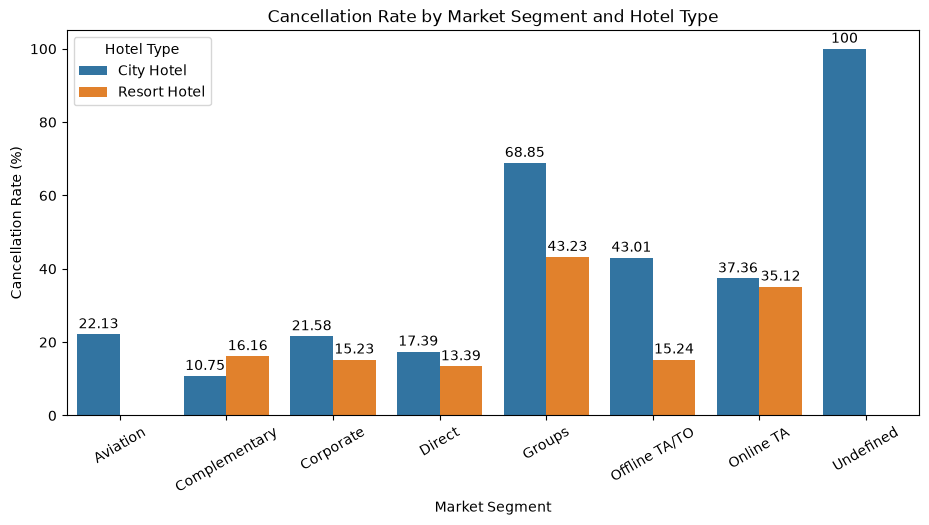

In [71]:
seg_cancel = df.groupby(['market_segment','hotel'], observed=True)['is_canceled'].mean().reset_index()
seg_cancel['cancel_rate'] = round(seg_cancel['is_canceled']*100, 2)

plt.figure(figsize=(11,5))
cancel = sns.barplot(data=seg_cancel, x='market_segment', y='cancel_rate', hue='hotel')
plt.title('Cancellation Rate by Market Segment and Hotel Type')
plt.xlabel('Market Segment')
plt.ylabel('Cancellation Rate (%)')
plt.xticks(rotation=30)
plt.legend(title='Hotel Type')
for i in cancel.containers:
    cancel.bar_label(i,padding=2)
plt.show()

Insights:
- "Groups" is by far the riskiest segment for City Hotel — 68.85% cancellation rate, its highest of
  any segment, and far above Resort Hotel's Groups rate (43.23%)
- "Complementary" (free/comp stays) cancels the least for City Hotel (10.75%) — consistent with our
  earlier zero-adr finding that comp bookings are the most reliable
- "Offline TA/TO" shows a striking gap: City Hotel cancels at 43.01% vs. Resort Hotel's much lower
  15.24% — the same channel behaves very differently depending on hotel type
- City Hotel cancels more than Resort Hotel in nearly every segment, reinforcing the overall pattern,
  but the size of that gap varies a lot by channel — Groups and Offline TA/TO show the widest gaps
- Note: the "Undefined" segment has only 2 rows (both City Hotel, both cancelled) — not statistically
  meaningful, just a data artifact worth excluding from strong conclusions
- Business takeaway: City Hotel should scrutinize Group and Offline TA/TO bookings most closely —
  these are the segments driving its overall higher cancellation rate

3.5 Does the price guests pay (ADR) change depending on how far in advance they book, and does this differ by hotel type?

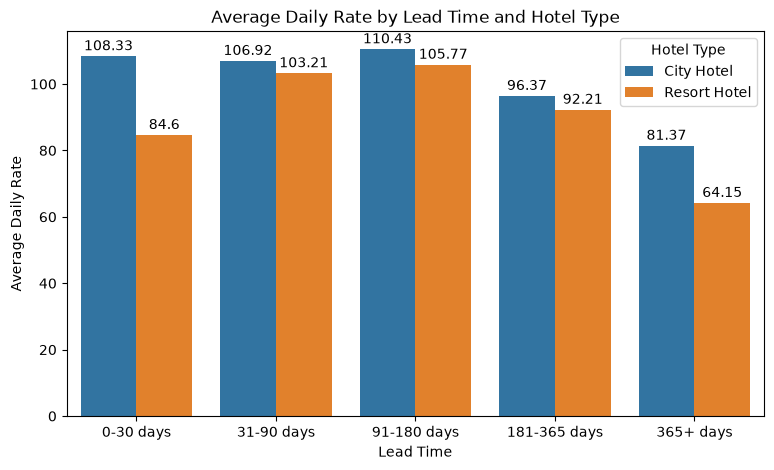

In [73]:
adr_lt = df.groupby(['lt_bucket','hotel'], observed=True)['adr'].mean().reset_index()
adr_lt['adr'] = round(adr_lt['adr'], 2)

plt.figure(figsize=(9,5))
adr = sns.barplot(data=adr_lt, x='lt_bucket', y='adr', hue='hotel')
plt.title('Average Daily Rate by Lead Time and Hotel Type')
plt.xlabel('Lead Time')
plt.ylabel('Average Daily Rate')
plt.legend(title='Hotel Type')
for i in adr.containers:
    adr.bar_label(i,padding=2)
plt.show()

Insights:

- For City Hotel, ADR stays fairly steady across most lead-time brackets (~106-110), only dropping
  for very last-minute (108, about the same) and very early (365+ days: 81.37) bookings
- Resort Hotel shows a clearer rising-then-falling pattern: lowest at 0-30 days (84.60), rising to a
  peak around 91-180 days (105.77), then dropping sharply for 365+ day bookings (64.15)
- Both hotel types charge their lowest average rates to guests booking 365+ days out — likely early-bird
  discount pricing to lock in demand far ahead of time
- Resort Hotel's last-minute guests (0-30 days) pay noticeably less than City Hotel's — possibly
  reflecting last-minute discounting to fill unsold rooms, since Resort Hotel bookings are more
  seasonal and harder to fill spontaneously outside peak periods
- Business takeaway: both hotels appear to reward far-advance booking with lower prices, but Resort
  Hotel's late-booking discounts suggest a "fill the room" pricing strategy for less predictable demand

## Conclusion

The EDA of **117,853 hotel bookings (2017–2019)** reveals that **City Hotel is more popular but carries a significantly higher cancellation risk** than Resort Hotel.

- **Longer stays** are associated with higher cancellation rates, with City Hotel showing the sharpest increase.
- **Longer lead times** also significantly increase cancellations, particularly for City Hotel bookings made several months in advance.
- City Hotel consistently records higher cancellations across **stay duration, lead time, deposit type, and market segments**.
- Resort Hotel shows stronger **seasonal demand**, with booking volume and ADR peaking around **September–October**.

## Key Recommendations

1. **Strengthen cancellation policies** for high-risk City Hotel segments, especially Group and Offline TA/TO bookings.
2. **Introduce deposits, reminders, or graduated cancellation fees** for bookings made far in advance.
3. **Use minimum-stay or partial-deposit requirements** for longer bookings to reduce revenue loss.
4. **Investigate Non Refund bookings**, which show an unusually high cancellation rate of **99.37%**.
5. **Leverage seasonal pricing** at Resort Hotel and test similar dynamic pricing strategies during City Hotel's peak-demand periods.

### Highest-Impact Recommendation

Prioritize **long-lead-time bookings**, as they show the strongest and most consistent increase in cancellation risk and therefore offer the greatest potential for **reducing revenue loss**.